# Read Data

In [1]:
import sys
sys.path.append('../')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import concurrent.futures
from tqdm import tqdm
import os
import glob


In [3]:
lcs = pd.read_parquet('../data/adquire/detections_adquired.parquet')
lcs = lcs.dropna(subset=['magpsf','mjd'])
lcs['oid'].nunique()

88265

In [4]:
#remove oids from supervised dataset 
path = '/home/fsoto/Documents/LCsSSL/data/rldl'
all_files = glob.glob(os.path.join(path, "*.csv"))

df_from_each_file = (pd.read_csv(f) for f in all_files)
df = pd.concat(df_from_each_file, ignore_index=True)


In [5]:
#remove oids from supervised dataset
lcs = lcs[~lcs.oid.isin(df.oid)]

In [6]:
lcs['oid'].nunique()

87635

In [7]:
lcs.columns

Index(['oid', 'candid', 'mjd', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid',
       'ra', 'dec', 'magpsf', 'sigmapsf', 'magap', 'sigmagap', 'distnr', 'rb',
       'rbversion', 'drb', 'drbversion', 'magapbig', 'sigmagapbig', 'rfid',
       'magpsf_corr', 'sigmapsf_corr', 'sigmapsf_corr_ext', 'corrected',
       'dubious', 'parent_candid', 'has_stamp', 'step_id_corr'],
      dtype='object')

In [8]:
lcs.head()

,oid,candid,mjd,fid,pid,diffmaglim,isdiffpos,nid,ra,dec,...,sigmagapbig,rfid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious,parent_candid,has_stamp,step_id_corr
0,ZTF17aaaaasb,524447461915010022,58278.447465,2,524447461915,20.7485,-1,524,326.109129,45.998860,...,0.0269,NaN,16.652930,100.0,0.007828,True,False,5.514534e+17,False,bulk_1.0.0
1,ZTF17aaaaasb,525449491915010021,58279.449491,1,525449491915,20.4968,-1,525,326.109177,45.998890,...,0.0672,NaN,17.798096,100.0,0.019789,True,False,5.514534e+17,False,bulk_1.0.0
2,ZTF17aaaaasb,526428191915015151,58280.428194,1,526428191915,20.9921,1,526,326.109085,45.998848,...,0.1507,NaN,17.194292,100.0,0.010051,True,False,5.514534e+17,False,bulk_1.0.0
3,ZTF17aaaaasb,526469201915010016,58280.469201,2,526469201915,20.7910,-1,526,326.109101,45.998858,...,0.0250,NaN,16.697813,100.0,0.007978,True,False,5.514534e+17,False,bulk_1.0.0
4,ZTF17aaaaasb,527433921915015032,58281.433924,1,527433921915,20.9268,1,527,326.109164,45.998879,...,0.1967,NaN,17.189240,100.0,0.010458,True,False,5.514534e+17,False,bulk_1.0.0


In [9]:
lcs['sigmapsf'].fillna(0, inplace=True)

/tmp/ipykernel_972973/2289526334.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lcs['sigmapsf'].fillna(0, inplace=True)


In [10]:
partitions = pd.read_parquet('../data/adquire/lc_classifier_periodic_adquired_detections.parquet')
partitions.rename(columns={'class_name':'alerceclass'}, inplace=True)
partitions.head()

,oid,classifier_name,classifier_version,alerceclass,probability,ranking
0,ZTF18abidhoe,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.514,1
1,ZTF18abrjkvt,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.680,1
2,ZTF18adlvixn,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.554,1
3,ZTF17aaaaasb,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.772,1
4,ZTF19abkalqp,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.684,1


In [11]:
classes = partitions['alerceclass'].unique()
classes

array(['LPV', 'Periodic-Other', 'E', 'RRL', 'DSCT', 'CEP'], dtype=object)

In [12]:
periodic_classes = ['LPV', 'Periodic-Other', 'E', 'DSCT', 'RRL', 'CEP']

In [13]:
partitions_periodic = partitions[partitions['alerceclass'].isin(periodic_classes)]
partitions_periodic.head()

,oid,classifier_name,classifier_version,alerceclass,probability,ranking
0,ZTF18abidhoe,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.514,1
1,ZTF18abrjkvt,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.680,1
2,ZTF18adlvixn,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.554,1
3,ZTF17aaaaasb,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.772,1
4,ZTF19abkalqp,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.684,1


In [14]:
partitions_periodic['alerceclass'].unique()

array(['LPV', 'Periodic-Other', 'E', 'RRL', 'DSCT', 'CEP'], dtype=object)

In [15]:
#Divide oids for train and evaluation 80% and 20% respectively stratified by class using sklearn
from sklearn.model_selection import train_test_split

train, eval = train_test_split(partitions_periodic, test_size=0.2, stratify=partitions_periodic['alerceclass'], random_state=42)

#add partition column with training and evaluation values
train['partition'] = 'training'
eval['partition'] = 'validation'

#concatenate train and evaluation partitions
partitions_periodic = pd.concat([train, eval])

In [16]:
unique_oids_periodic = partitions_periodic['oid'].unique()
len(unique_oids_periodic)

88265

In [24]:
periods = pd.read_parquet('../data/adquire/detections_periods_adquired.parquet')
periods.shape

(88265, 5)

In [18]:
periodic_classes_reduced = ['LPV', 'Periodic-Other', 'E', 'DSCT', 'RRL', 'CEP']

In [19]:
partitions_periodic_reduced = partitions_periodic[partitions_periodic['alerceclass'].isin(periodic_classes_reduced)]
partitions_periodic_reduced_unique = partitions_periodic_reduced.drop_duplicates(subset='oid')
partitions_periodic_reduced_oids = partitions_periodic_reduced['oid'].unique()

In [20]:
periods_reduced = periods[periods['oid'].isin(partitions_periodic_reduced_oids)]
len(periods_reduced)

88265

In [21]:
oids_with_period = periods_reduced['oid'].unique()

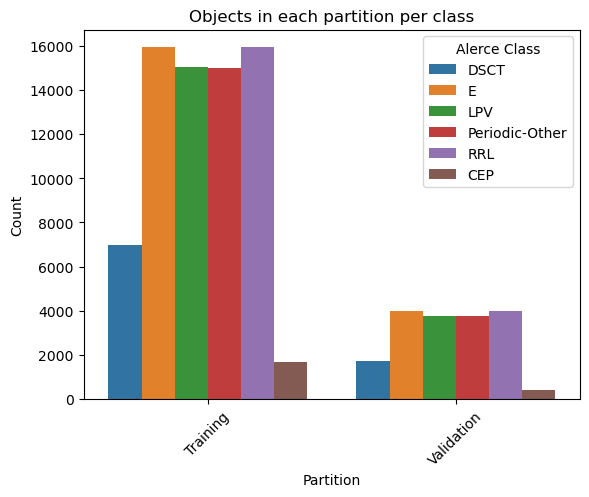

In [23]:
sns.countplot(data=partitions_periodic_reduced, x='partition', hue='alerceclass')

# Añadir títulos y etiquetas
plt.title('Objects in each partition per class')
#change x-axis labels to Training and Validation insted of partition
plt.xticks(ticks=[0,1], labels=['Training', 'Validation'])
#change legend title to Alerce Class
plt.legend(title='Alerce Class')

plt.xlabel('Partition')
plt.ylabel('Count')
# Rotate the x-axis labels
plt.xticks(rotation=45)
# Mostrar el gráfico
plt.show()

In [30]:
objects_with_period = partitions_periodic_reduced[partitions_periodic_reduced['oid'].isin(oids_with_period)]
objects_with_period = pd.merge(objects_with_period, periods_reduced[['oid', 'value']], on='oid', how='left')
objects_with_period = objects_with_period.rename(columns={'value': 'period'})
objects_with_period.head()

,oid,classifier_name,classifier_version,alerceclass,probability,ranking,partition,period
0,ZTF18adndeka,lc_classifier_periodic,hierarchical_rf_1.1.0,DSCT,0.898,1,training,0.285865
1,ZTF18aavedio,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.536,1,training,0.364557
2,ZTF18abioscv,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.590,1,training,0.142531
3,ZTF18aayusqz,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.694,1,training,0.062633
4,ZTF20acnroti,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.744,1,training,0.642673


In [31]:
objects_with_period.shape

(88265, 8)

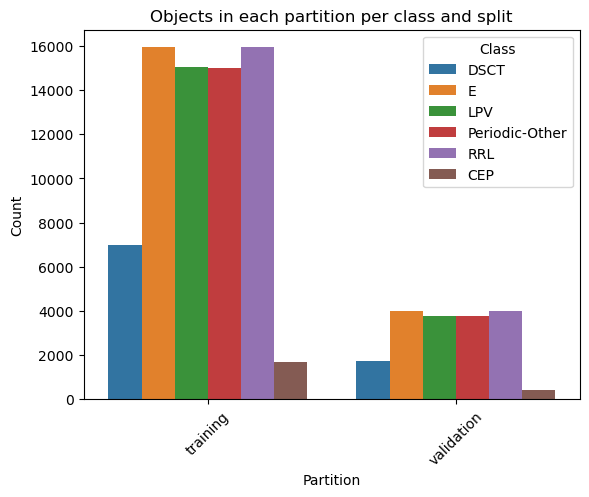

In [32]:
ax =sns.countplot(data=objects_with_period, x='partition', hue='alerceclass')
plt.title('Objects in each partition per class and split')
ax.legend(loc='upper right',title='Class')
plt.xlabel('Partition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [33]:
objects_with_periods_unique = objects_with_period.drop_duplicates(subset='oid')

In [34]:
filtered_lcs = lcs[lcs['oid'].isin(objects_with_periods_unique['oid'])]

In [35]:
objects_with_periods_unique

,oid,classifier_name,classifier_version,alerceclass,probability,ranking,partition,period
0,ZTF18adndeka,lc_classifier_periodic,hierarchical_rf_1.1.0,DSCT,0.898,1,training,0.285865
1,ZTF18aavedio,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.536,1,training,0.364557
2,ZTF18abioscv,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.590,1,training,0.142531
3,ZTF18aayusqz,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.694,1,training,0.062633
4,ZTF20acnroti,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.744,1,training,0.642673
...,...,...,...,...,...,...,...,...
88260,ZTF19acakqzr,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.554,1,validation,0.977517
88261,ZTF17aabocly,lc_classifier_periodic,hierarchical_rf_1.1.0,RRL,0.838,1,validation,0.581217
88262,ZTF18abzwldl,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.670,1,validation,0.304336
88263,ZTF18aayvfzr,lc_classifier_periodic,hierarchical_rf_1.1.0,DSCT,0.530,1,validation,0.289687


In [36]:
filtered_lcs_with_class  = pd.merge(filtered_lcs, objects_with_periods_unique[['oid','alerceclass','period']], on='oid', how='left')

In [37]:
filtered_lcs_with_class

,oid,candid,mjd,fid,pid,diffmaglim,isdiffpos,nid,ra,dec,...,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious,parent_candid,has_stamp,step_id_corr,alerceclass,period
0,ZTF17aaaaasb,524447461915010022,58278.447465,2,524447461915,20.748500,-1,524,326.109129,45.998860,...,16.652930,100.0,0.007828,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711
1,ZTF17aaaaasb,525449491915010021,58279.449491,1,525449491915,20.496800,-1,525,326.109177,45.998890,...,17.798096,100.0,0.019789,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711
2,ZTF17aaaaasb,526428191915015151,58280.428194,1,526428191915,20.992100,1,526,326.109085,45.998848,...,17.194292,100.0,0.010051,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711
3,ZTF17aaaaasb,526469201915010016,58280.469201,2,526469201915,20.791000,-1,526,326.109101,45.998858,...,16.697813,100.0,0.007978,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711
4,ZTF17aaaaasb,527433921915015032,58281.433924,1,527433921915,20.926800,1,527,326.109164,45.998879,...,17.189240,100.0,0.010458,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15775457,ZTF21abpuzhi,2756334140415015008,60510.334143,2,2756334140415,19.284933,1,2756,306.136661,-19.346044,...,15.097995,100.0,0.008559,True,False,NaN,True,24.5.1,DSCT,0.057493
15775458,ZTF21abpuzhi,2796344120415015012,60550.344120,1,2796344120415,19.934700,1,2796,306.136780,-19.346150,...,15.175550,100.0,0.007210,True,False,2.823279e+18,False,24.5.1,DSCT,0.057493
15775459,ZTF21abpuzhi,2798329280415010012,60552.329282,1,2798329280415,19.956300,-1,2798,306.136795,-19.345970,...,15.430573,100.0,0.008689,True,False,2.823279e+18,False,24.5.1,DSCT,0.057493
15775460,ZTF21abpuzhi,2817275060415015004,60571.275069,1,2817275060415,18.716000,1,2817,306.136785,-19.346169,...,15.198757,100.0,0.009994,True,False,2.823279e+18,False,24.5.1,DSCT,0.057493


In [39]:
['EA', 'RRLc', 'RSCVn', 'EB/EW', 'LPV', 'CEP', 'RRLab', 'Periodic-Other', 'DSCT']

['EA',
 'RRLc',
 'RSCVn',
 'EB/EW',
 'LPV',
 'CEP',
 'RRLab',
 'Periodic-Other',
 'DSCT']

In [40]:
'LPV', 'Periodic-Other', 'E', 'DSCT', 'RRL', 'CEP'

('LPV', 'Periodic-Other', 'E', 'DSCT', 'RRL', 'CEP')

In [41]:
#apply labels to alerceclass
labels = {
    "LPV": 0,
    "CEP": 1,
    "E": 2,
    "RRL": 3,
    "Periodic-Other": 4,
    "DSCT": 5
}
filtered_lcs_with_class['label'] = filtered_lcs_with_class['alerceclass'].apply(lambda x: labels[x])
filtered_lcs_with_class.head()

,oid,candid,mjd,fid,pid,diffmaglim,isdiffpos,nid,ra,dec,...,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious,parent_candid,has_stamp,step_id_corr,alerceclass,period,label
0,ZTF17aaaaasb,524447461915010022,58278.447465,2,524447461915,20.7485,-1,524,326.109129,45.998860,...,100.0,0.007828,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711,2
1,ZTF17aaaaasb,525449491915010021,58279.449491,1,525449491915,20.4968,-1,525,326.109177,45.998890,...,100.0,0.019789,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711,2
2,ZTF17aaaaasb,526428191915015151,58280.428194,1,526428191915,20.9921,1,526,326.109085,45.998848,...,100.0,0.010051,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711,2
3,ZTF17aaaaasb,526469201915010016,58280.469201,2,526469201915,20.7910,-1,526,326.109101,45.998858,...,100.0,0.007978,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711,2
4,ZTF17aaaaasb,527433921915015032,58281.433924,1,527433921915,20.9268,1,527,326.109164,45.998879,...,100.0,0.010458,True,False,5.514534e+17,False,bulk_1.0.0,E,0.126711,2


In [42]:
#find all the rows with a nan or non value
filtered_lcs_with_class[filtered_lcs_with_class['magpsf'].isnull()]

,oid,candid,mjd,fid,pid,diffmaglim,isdiffpos,nid,ra,dec,...,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious,parent_candid,has_stamp,step_id_corr,alerceclass,period,label


In [43]:
def process_bins(lc, n_bins, sensibilidad,row_name='mjd'):
    if len(lc) > 150 and n_bins > 10:
        bins = pd.cut(lc[row_name], bins=n_bins, duplicates='drop')
        bin_counts = bins.value_counts().sort_values(ascending=False)
        mean_bin_counts = bin_counts.mean()
        std_bin_counts = bin_counts.std()

        # Identify bins exceeding threshold
        removed_bin_index = bin_counts[bin_counts > mean_bin_counts + sensibilidad * std_bin_counts].index

        # Select and remove rows from the original DataFrame
        removed_bin_lc = lc[bins.isin(removed_bin_index)]
        lc = lc[~bins.isin(removed_bin_index)]

        # Check if removed_bin_lc is empty before trying to bin it
        if not removed_bin_lc.empty:
            # Recompute bins for the removed rows to avoid reindexing issues
            removed_bin_lc_bins = pd.cut(removed_bin_lc[row_name], bins=n_bins, duplicates='drop')

            # Randomly sample values from removed bins
            random_samples = []
            for bin in removed_bin_index:
                bin_data = removed_bin_lc[removed_bin_lc_bins == bin]
                sample_size = int(mean_bin_counts)
                if len(bin_data) >= sample_size:
                    sampled_data = bin_data.sample(n=sample_size, random_state=42)
                else:
                    sampled_data = bin_data
                random_samples.append(sampled_data)

            # Concatenate sampled rows
            if random_samples:  # Ensure there's data to concatenate
                random_sampled_rows = pd.concat(random_samples)
                lc = pd.concat([lc, random_sampled_rows])

    return lc
def process_group(group, del_bin=True, bins_percent=0.5, sensibilidad=10):
    #find nan values in group in column mag_tot and mjd and fid and remove them rows
    group = group.dropna(subset=['magpsf', 'mjd', 'fid'])
    oid = group['oid'].values[0]
    rows = group
    removed = None
    removed_count = 0
    #substract mjd min to all mjd values
    if del_bin:
        red_lc = rows[rows['fid'] == 2].copy()
        green_lc = rows[rows['fid'] == 1].copy()

        n_bins_red = int(len(red_lc) * bins_percent)
        n_bins_green = int(len(green_lc) * bins_percent)

        count = len(red_lc) + len(green_lc) 
        red_lc = process_bins(red_lc, n_bins_red, sensibilidad, row_name='mjd')
        green_lc = process_bins(green_lc, n_bins_green, sensibilidad, row_name='mjd')

        red_lc = process_bins(red_lc, n_bins_red, sensibilidad, row_name='magpsf')
        green_lc = process_bins(green_lc, n_bins_green, sensibilidad, row_name='magpsf')
        new_count = len(red_lc) + len(green_lc)
        # Combine red and green light curves
        rows = pd.concat([red_lc, green_lc])
        if count != new_count:
            removed = oid
            removed_count = count - new_count
    rows = rows.sort_values('mjd')
    rows['mjd'] = rows['mjd'] - rows['mjd'].min()  # Normalize mjd

    # Initialize arrays
    max_size = 1000
    mjds = np.zeros((max_size, 2))
    mags = np.zeros((max_size, 2))
    sigma_mags = np.zeros((max_size, 2))
    fids = np.zeros((max_size, 2))
    masks = np.zeros((max_size, 2))

    for fid in [1, 2]:
        fid_rows = rows[rows['fid'] == fid]
        size = min(max_size, len(fid_rows))

        # Fill arrays up to the allowed size
        mjds[:size, fid - 1] = fid_rows['mjd'].values[:size]
        mags[:size, fid - 1] = fid_rows['magpsf'].values[:size]
        sigma_mags[:size, fid - 1] = fid_rows['sigmapsf'].values[:size]
        fids[:size, fid - 1] = fid_rows['fid'].values[:size]
        masks[:size, fid - 1] = (fid_rows['magpsf'].values[:size] != 0).astype(int)

    # Get the period and label from the group
    period = group['period'].values[0]
    label = group['label'].values[0]

    return oid, mjds, mags,sigma_mags, fids, masks, period, label, removed, removed_count

In [44]:
# Agrupar el dataframe por 'oid'
grouped_lcs = filtered_lcs_with_class.groupby('oid')

In [45]:
import functools
partial_process_group = functools.partial(process_group,del_bin= False, bins_percent=0.05, sensibilidad=3)


In [46]:


# Uso de ProcessPoolExecutor para paralelizar el procesamiento
results = []
with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(partial_process_group, [group for _, group in grouped_lcs]), total=len(grouped_lcs)))

# Desempaquetar los resultados
oids_array, mjds_array, mags_array,sigma_mags_array, fids, masks_array, periods_array,label_array, remove_array,removed_count = zip(*results)

# Convertir a arrays de numpy
mjds_array = np.stack(mjds_array)
mags_array = np.stack(mags_array)
sigma_mags_array = np.stack(sigma_mags_array)
masks_array = np.stack(masks_array)
periods_array = np.array(periods_array)
oids_array = np.array(oids_array)
label_array = np.array(label_array)
fids_array = np.stack(fids)
remove_array = np.array(remove_array)
removed_count = np.array(removed_count)

100%|██████████| 87635/87635 [00:56<00:00, 1555.57it/s]


In [47]:
#find nan values
nan_values = np.argwhere(np.isnan(mags_array))
nan_values


array([], shape=(0, 3), dtype=int64)

In [48]:
masks_array.sum()/len(filtered_lcs_with_class)

0.9991069041274354

In [49]:
#create a dataframe with removed oids and removed count
removed_df = pd.DataFrame({'oid': remove_array, 'removed_count': removed_count})

In [50]:
#remove None values and order by removed_count

removed_df = removed_df[removed_df['oid'].notnull()]
removed_df = removed_df.sort_values('removed_count', ascending=False)

In [51]:
removed_df.head(20)

,oid,removed_count


In [52]:
masks_array.sum()

15761373.0

In [53]:
def get_positions(partition,oids_array,splits):
    oids = splits[splits['partition'] == partition]['oid'].values
    posiciones = []
    for i in oids:
        posiciones.append(np.where(oids_array == i)[0][0])
    posiciones = sorted(posiciones)
    return posiciones


In [54]:
#remove from objects with period the objects that are not in oids_array
objects_with_period = objects_with_period[objects_with_period['oid'].isin(oids_array)]

In [55]:
training_0_list = get_positions('training',oids_array,objects_with_period)

validation_0_list = get_positions('validation',oids_array,objects_with_period)


In [56]:
import os
import h5py

In [57]:
masks_array.sum()/len(filtered_lcs_with_class)

0.9991069041274354

In [58]:
name = 'detections_adquired_v2.h5'

In [59]:
if os.path.exists(name):
    os.remove(name)

with h5py.File(name, 'w') as f:
    f.create_dataset('oid', data=np.array(oids_array, dtype='S'))
    f.create_dataset('labels', data=label_array)
    f.create_dataset('time', data=mjds_array)
    f.create_dataset('mag_tot', data=mags_array)
    f.create_dataset('err_tot', data=sigma_mags_array)
    f.create_dataset('fid', data=fids_array)
    f.create_dataset('Multiband_period', data=periods_array)
    f.create_dataset('mask', data=masks_array)
    f.create_dataset('training', data=training_0_list)
    f.create_dataset('validation', data=validation_0_list)


In [60]:
f.close()